# Histogram MLP — Kinematic Features

Supervised MLP trained on histogram-of-kinematic-features, using the **same**:
- train/val/test split as the LSTM (884 / 195 / 54)
- soft cross-entropy loss (human response distributions from Study 1)
- cosine distance on penultimate-layer embeddings for similarity

**What this isolates for the reviewer:**
- Histogram → Histogram MLP: adds supervision only (no dynamics)
- Histogram MLP → LSTM: adds temporal dynamics only (supervision held constant)

Kinematic features (replicating MATLAB `get_kinematic_feat_dmat.m`):
- velocity (vx_A, vy_A, vx_B, vy_B) — 4 features
- acceleration (ax_A, ay_A, ax_B, ay_B) — 4 features
- inter-agent distance (d_AB) — 1 feature
- 9 features × 200 bins = **1800-dim histogram vector** per animation

## 0. Imports & paths

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from scipy.spatial.distance import cosine
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import os

onehot = False
# ── Paths ──────────────────────────────────────────────────────────────────
TRAJ_XLSX       = './../lstm/data/charades_traj_summary_selected1133.xlsx'
TRAIN_CSV       = './../lstm/data/charades_traj_train.csv'
VAL_CSV         = './../lstm/data/charades_traj_val.csv'
PART1_XLSX      = './../lstm/data/charades_participant.xlsx'
PART2_XLSX      = './../lstm/data/charades_participant_diffStim.xlsx'
SOFT_LABEL_CSV  = './../lstm/data/one_hot.csv'if onehot else './../lstm/data/732subj_response_distributions.csv'
HUMAN_DMAT      = './../../human/behavioralExpDataAndAnalysis/exp2/full_dmat_585subj_hcordered.csv'  

OUT_DIR = './distMat'
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs('./results', exist_ok=True)

In [2]:
os.getcwd()

'/Users/yilingyun/Downloads/latent_force_model_project_6_10/models/histo_static'

## 1. Load soft labels (human response distributions from Study 1)

In [3]:
soft_df = pd.read_csv(SOFT_LABEL_CSV, sep='\t')

# Extract integer video ID from 'ID_label' index column
soft_df['id'] = soft_df['Unnamed: 0'].str.split('_').str[0].astype(int)
soft_df = soft_df.drop(columns=['Unnamed: 0'])

# Label columns are Title Case — normalise to lowercase to match label2idx later
label_cols_raw = [c for c in soft_df.columns if c != 'id']
label_cols_lower = [c.lower() for c in label_cols_raw]
soft_df.columns = label_cols_lower + ['id']

# Build {video_id: np.array(32,)} lookup
soft_label_map = {
    int(row['id']): row[label_cols_lower].values.astype(np.float32)
    for _, row in soft_df.iterrows()
}

ALL_LABELS = label_cols_lower   # 32 labels, alphabetical
label2idx  = {l: i for i, l in enumerate(ALL_LABELS)}

print(f'Soft labels loaded: {len(soft_label_map)} animations × {len(ALL_LABELS)} classes')
print('Row sum check (should be ~1.0):', soft_df[label_cols_lower].sum(axis=1).describe()[['min','max']])

Soft labels loaded: 1156 animations × 32 classes
Row sum check (should be ~1.0): min    1.0
max    1.0
dtype: float64


## 2. Load trajectory data

In [4]:
def parse_coord(cell_str):
    """Parse trajectory string ['1500.0', '1500.4', ...] into float array."""
    s = str(cell_str).strip().replace("['", "").replace("']", "")
    parts = [x.strip().strip("'") for x in s.split(",")]
    return np.array([float(p) for p in parts if p])


def load_trajectories(xlsx_path, sheet='all'):
    df = pd.read_excel(xlsx_path, sheet_name=sheet, header=0)
    trajs = {}
    for _, row in df.iterrows():
        vid_id = int(row['id'])
        trajs[vid_id] = {
            'x1': parse_coord(row['x1']),
            'y1': parse_coord(row['y1']),
            'x2': parse_coord(row['x2']),
            'y2': parse_coord(row['y2']),
            'label': str(row['label']).lower(),
        }
    return trajs


trajs = load_trajectories(TRAJ_XLSX, sheet='summary')
print(f'Loaded {len(trajs)} animations from trajectory file')

Loaded 1133 animations from trajectory file


## 3. Compute kinematic features (replicates MATLAB exactly)

1. Pad 11 frames at start
2. Stride with interval = 5
3. Velocity = diff, Acceleration = diff of diff, Distance = Euclidean
4. Remove zero-movement frames before histogramming

In [5]:
def compute_kinematic_features(x1, y1, x2, y2):
    """
    Returns array (T_windows, 9):
    [vx_A, vy_A, vx_B, vy_B, ax_A, ay_A, ax_B, ay_B, dist_AB]
    """
    dataraw0 = np.stack([x1, y1, x2, y2], axis=1)          # (T, 4)

    # Step 1: pad 11 frames at start
    pad      = np.tile(dataraw0[0], (11, 1))
    dataraw0 = np.vstack([pad, dataraw0])                   # (T+11, 4)

    # Step 2: stride — select every 5th frame, skip first and last intv
    intv     = 5
    framenum = dataraw0.shape[0]
    framesel = np.arange(intv, framenum - intv, intv)       # matches MATLAB 1+intv:intv:end-intv
    dataraw  = dataraw0[framesel]                           # (T', 4)

    # Distance between agents
    datadist = np.sqrt((dataraw[:, 0] - dataraw[:, 2])**2 +
                       (dataraw[:, 1] - dataraw[:, 3])**2) # (T',)

    # Velocity: pad first frame then diff
    datav = np.diff(np.vstack([dataraw[0:1], dataraw]), axis=0)   # (T', 4)

    # Acceleration: pad first velocity then diff
    dataa = np.diff(np.vstack([datav[0:1], datav]), axis=0)       # (T', 4)

    # [vel(4), acc(4), dist(1)] → (T', 9)
    return np.hstack([datav, dataa, datadist[:, None]])


feat_dict = {}
for vid_id, traj in trajs.items():
    feat_dict[vid_id] = compute_kinematic_features(
        traj['x1'], traj['y1'], traj['x2'], traj['y2']
    )

sample_id = list(feat_dict.keys())[0]
print(f'Features computed for {len(feat_dict)} animations')
print(f'Sample shape: {feat_dict[sample_id].shape}  (T_windows × 9 features)')

Features computed for 1133 animations
Sample shape: (66, 9)  (T_windows × 9 features)


## 4. Compute bin edges from ALL animations, then build histogram vectors

In [6]:
# Global mean/std across all windows (matching MATLAB rstparamat)
all_features = np.vstack(list(feat_dict.values()))  # (N_windows_total, 9)
mean_para    = all_features.mean(axis=0)
std_para     = all_features.std(axis=0)

N_BINS    = 200
STD_SCALE = 20
n_feat    = 9

bin_edges = [
    np.linspace(mean_para[fi] - STD_SCALE * std_para[fi],
                mean_para[fi] + STD_SCALE * std_para[fi],
                N_BINS)
    for fi in range(n_feat)
]
print(f'Bin edges: {N_BINS} bins per feature, range = mean ± {STD_SCALE}σ')

Bin edges: 200 bins per feature, range = mean ± 20σ


In [7]:
def compute_histogram_vector(features, bin_edges):
    """
    features: (T, 9)
    Returns: flattened histogram vector (9 × (N_BINS-1),)
    """
    # Remove zero-movement frames (matching MATLAB indx_d)
    zero_mask = np.sum(np.abs(features[:, :4]), axis=1) == 0
    features  = features[~zero_mask]

    hists = []
    for fi in range(features.shape[1]):
        counts, _ = np.histogram(features[:, fi], bins=bin_edges[fi])
        total     = counts.sum()
        prob      = counts / total if total > 0 else counts.astype(float)
        hists.append(prob)
    return np.array(hists).flatten()   # (9 × 199,) ≈ 1791-dim


hist_dict = {vid_id: compute_histogram_vector(feats, bin_edges)
             for vid_id, feats in feat_dict.items()}

INPUT_DIM = hist_dict[sample_id].shape[0]
print(f'Histogram vector dim: {INPUT_DIM}')

Histogram vector dim: 1791


## 5. Build train / val / test splits

Val filtered against `selected_1133` to exclude animations <24 frames (ID 6014),
giving 884 / 195 / 54 — matching the manuscript.

In [8]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
p1       = pd.read_excel(PART1_XLSX)
p2       = pd.read_excel(PART2_XLSX)
test_df  = pd.concat([p1, p2]).reset_index(drop=True)

# Use selected_1133 as the valid ID set (excludes <24 frame animations)
df_sel      = pd.read_excel(TRAJ_XLSX, sheet_name='summary')
valid_ids   = set(df_sel['id'].tolist())

train_ids = [i for i in train_df['ID'].tolist() if i in valid_ids]
val_ids   = [i for i in val_df['ID'].tolist()   if i in valid_ids]   # → 195
test_ids  = [i for i in test_df['ID'].tolist()  if i in hist_dict]   # → 54

print(f'Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}')
# Expected: 884 / 195 / 54

Train: 884, Val: 195, Test: 54


In [9]:
def build_tensors(ids, hist_dict, soft_label_map, label2idx, id_label_map):
    X, Y = [], []
    for vid_id in ids:
        X.append(hist_dict[vid_id])
        if vid_id in soft_label_map:
            Y.append(soft_label_map[vid_id])          # 32-dim human distribution
        else:
            # Fallback: one-hot from label string (should not happen for train/val)
            one_hot = np.zeros(len(label2idx), dtype=np.float32)
            lbl = id_label_map.get(vid_id, '')
            if lbl in label2idx:
                one_hot[label2idx[lbl]] = 1.0
            Y.append(one_hot)
            print(f'  Warning: no soft label for ID {vid_id}, using one-hot')
    return (torch.tensor(np.array(X), dtype=torch.float32),
            torch.tensor(np.array(Y), dtype=torch.float32))


# Build ID→label lookup
id_label_map = {}
for _, row in pd.concat([train_df, val_df, test_df]).iterrows():
    id_label_map[int(row['ID'])] = str(row['label']).lower()

X_train, Y_train = build_tensors(train_ids, hist_dict, soft_label_map, label2idx, id_label_map)
X_val,   Y_val   = build_tensors(val_ids,   hist_dict, soft_label_map, label2idx, id_label_map)
X_test,  _       = build_tensors(test_ids,  hist_dict, soft_label_map, label2idx, id_label_map)

print(f'X_train: {X_train.shape}, Y_train: {Y_train.shape}')
print(f'X_val:   {X_val.shape},   Y_val:   {Y_val.shape}')
print(f'X_test:  {X_test.shape}')

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   Y_val),   batch_size=64, shuffle=False)

X_train: torch.Size([884, 1791]), Y_train: torch.Size([884, 32])
X_val:   torch.Size([195, 1791]),   Y_val:   torch.Size([195, 32])
X_test:  torch.Size([54, 1791])


## 6. Define MLP

Two hidden layers × 64 units — mirrors LSTM hidden size.
Penultimate 64-dim layer = embedding for cosine similarity.

In [10]:
class HistogramMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=32, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, hidden_dim),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        emb    = self.encoder(x)
        logits = self.classifier(emb)
        return logits, emb

    def get_embedding(self, x):
        with torch.no_grad():
            return self.encoder(x)

## 7. Train with soft cross-entropy (same objective as LSTM)

In [11]:
def soft_cross_entropy(logits, soft_targets):
    log_probs = torch.log_softmax(logits, dim=-1)
    return -(soft_targets * log_probs).sum(dim=-1).mean()


def train_model(model, train_loader, val_loader,
                n_epochs=200, lr=0.003, patience=15):
    optimizer  = optim.Adam(model.parameters(), lr=lr)
    best_val   = float('inf')
    best_state = None
    wait       = 0
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits, _ = model(xb)
            loss = soft_cross_entropy(logits, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_losses.append(np.mean(batch_losses))

        model.eval()
        with torch.no_grad():
            val_loss = np.mean([
                soft_cross_entropy(model(xb)[0], yb).item()
                for xb, yb in val_loader
            ])
        val_losses.append(val_loss)

        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1:3d} | train {train_losses[-1]:.4f} | val {val_loss:.4f}')

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses


torch.manual_seed(1)
model = HistogramMLP(input_dim=INPUT_DIM, hidden_dim=64, output_dim=len(ALL_LABELS))
model, train_losses, val_losses = train_model(
    model, train_loader, val_loader, n_epochs=200, lr=0.003, patience=15
)

Epoch  20 | train 2.5881 | val 3.0487
Early stopping at epoch 37


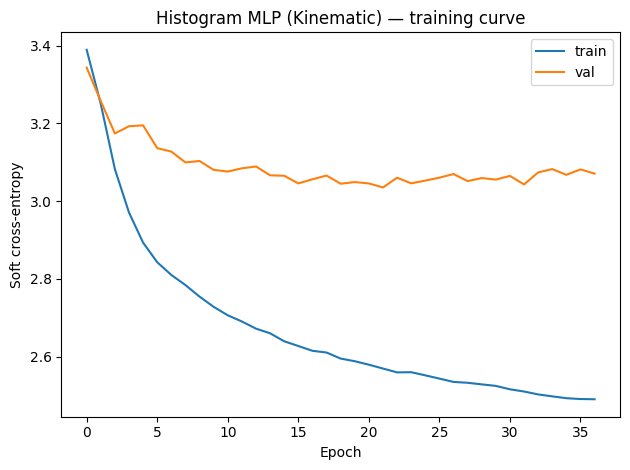

In [12]:
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='val')
plt.xlabel('Epoch'); plt.ylabel('Soft cross-entropy')
plt.title('Histogram MLP (Kinematic) — training curve')
plt.legend(); plt.tight_layout(); plt.show()

## 8. Extract penultimate-layer embeddings for the 54 test animations

In [13]:
model.eval()
embeddings_test = model.get_embedding(X_test).numpy()  # (54, 64)
print(f'Test embeddings: {embeddings_test.shape}')

Test embeddings: (54, 64)


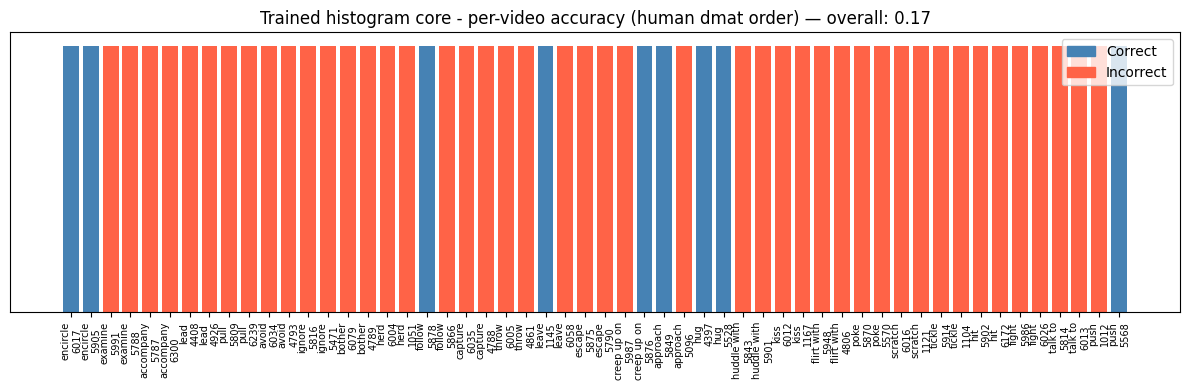


By category:
  encircle        2/2
  examine         0/2
  accompany       0/2
  lead            0/2
  pull            0/2
  avoid           0/2
  ignore          0/2
  bother          0/2
  herd            0/2
  follow          1/2
  capture         0/2
  throw           0/2
  leave           1/2
  escape          0/2
  creep up on     1/2
  approach        1/2
  hug             2/2
  huddle with     0/2
  kiss            0/2
  flirt with      0/2
  poke            0/2
  scratch         0/2
  tickle          0/2
  hit             0/2
  fight           0/2
  talk to         0/2
  push            1/2


In [14]:
# Per-video accuracy ordered by human dmat label order
idx2label = {i: l for l, i in label2idx.items()}

# Reorder test_ids to match human dmat order
human_df  = pd.read_csv(HUMAN_DMAT, sep='\t', index_col=0)
human_ids = [int(x.split('_')[0]) for x in human_df.index]
human_labels = [x.split('_')[1] for x in human_df.index]

model.eval()
with torch.no_grad():
    # Get predictions in human dmat order
    reorder_idx = [test_ids.index(i) for i in human_ids]
    X_test_ordered = X_test[reorder_idx]
    logits, _ = model(X_test_ordered)
    pred_idx  = logits.argmax(dim=-1)

true_idx  = torch.tensor([label2idx[id_label_map[i]] for i in human_ids])
correct   = (pred_idx == true_idx).numpy()

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['steelblue' if c else 'tomato' for c in correct]
ax.bar(range(len(human_ids)), np.ones(len(human_ids)), color=colors, width=0.8)
ax.set_xticks(range(len(human_ids)))
ax.set_xticklabels(
    [f'{l}\n{i}' for l, i in zip(human_labels, human_ids)],
    rotation=90, fontsize=7
)
ax.set_yticks([])
ax.set_title(f'Trained histogram core - per-video accuracy (human dmat order) — overall: {correct.mean():.2f}')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Correct'),
                   Patch(color='tomato',    label='Incorrect')],
          loc='upper right')
plt.tight_layout()
plt.show()

# Print summary per category
print('\nBy category:')
seen = {}
for i, (vid_id, lbl, c) in enumerate(zip(human_ids, human_labels, correct)):
    seen.setdefault(lbl, []).append(c)
for lbl, results in seen.items():
    print(f'  {lbl:<15} {sum(results)}/{len(results)}')

In [15]:
# Test accuracy — ground truth = argmax of human response distribution
model.eval()
with torch.no_grad():
    logits, _ = model(X_test)
    pred_idx  = logits.argmax(dim=-1)

# Ground truth: most frequent human response label (argmax of soft distribution)
true_idx = torch.tensor([
    np.argmax(soft_label_map[vid_id]) for vid_id in test_ids
])

accuracy = (pred_idx == true_idx).float().mean().item()
print(f'Test accuracy: {accuracy:.2f}')

Test accuracy: 0.26


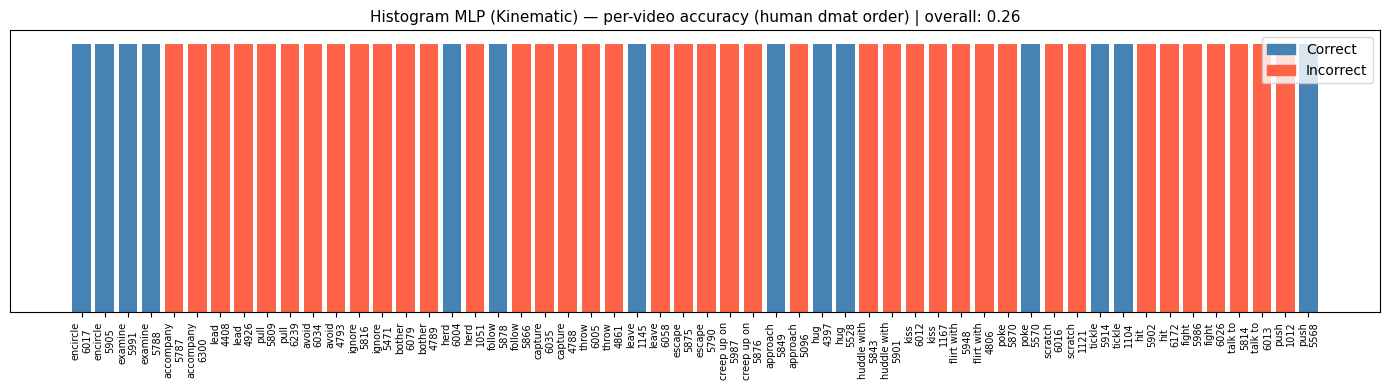


By category:
  accompany       0/2
  approach        1/2
  avoid           0/2
  bother          0/2
  capture         0/2
  creep up on     0/2
  encircle        2/2
  escape          0/2
  examine         2/2
  fight           0/2
  flirt with      0/2
  follow          1/2
  herd            1/2
  hit             0/2
  huddle with     0/2
  hug             2/2
  ignore          0/2
  kiss            0/2
  lead            0/2
  leave           1/2
  poke            1/2
  pull            0/2
  push            1/2
  scratch         0/2
  talk to         0/2
  throw           0/2
  tickle          2/2


In [16]:
# Per-video accuracy in human dmat order
idx2label = {i: l for l, i in label2idx.items()}

# Reorder test to human dmat order
human_df       = pd.read_csv(HUMAN_DMAT, sep='\t', index_col=0)
human_ids      = [int(x.split('_')[0]) for x in human_df.index]
human_labels   = [x.split('_')[1]      for x in human_df.index]

model.eval()
with torch.no_grad():
    reorder_idx    = [test_ids.index(i) for i in human_ids]
    X_test_ordered = X_test[reorder_idx]
    logits, _      = model(X_test_ordered)
    pred_idx       = logits.argmax(dim=-1)

true_idx = torch.tensor([
    np.argmax(soft_label_map[i]) for i in human_ids
])
correct = (pred_idx == true_idx).numpy()

# ── Bar plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
colors  = ['steelblue' if c else 'tomato' for c in correct]
ax.bar(range(len(human_ids)), np.ones(len(human_ids)), color=colors, width=0.8)
ax.set_xticks(range(len(human_ids)))
ax.set_xticklabels(
    [f'{lbl}\n{vid}' for lbl, vid in zip(human_labels, human_ids)],
    rotation=90, fontsize=7
)
ax.set_yticks([])
ax.set_title(
    f'Histogram MLP (Kinematic) — per-video accuracy (human dmat order) | overall: {correct.mean():.2f}',
    fontsize=11
)
ax.legend(handles=[
    plt.matplotlib.patches.Patch(color='steelblue', label='Correct'),
    plt.matplotlib.patches.Patch(color='tomato',    label='Incorrect')
], loc='upper right')
plt.tight_layout()
plt.show()

# ── Per-category summary ────────────────────────────────────────────────────
print('\nBy category:')
from collections import defaultdict
cat_results = defaultdict(list)
for lbl, c in zip(human_labels, correct):
    cat_results[lbl].append(c)
for lbl, vals in sorted(cat_results.items()):
    print(f'  {lbl:<15} {sum(vals)}/{len(vals)}')

## 9. Compute cosine distance matrix (54 × 54)

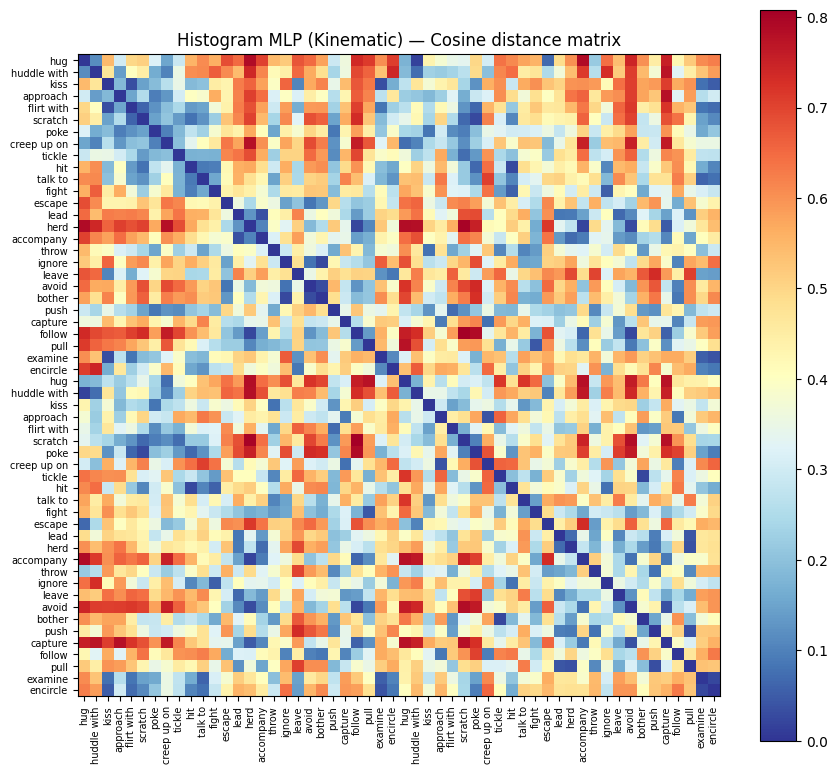

In [17]:
n_test = len(test_ids)
dist_matrix = np.zeros((n_test, n_test))
for i in range(n_test):
    for j in range(n_test):
        if i != j:
            dist_matrix[i, j] = cosine(embeddings_test[i], embeddings_test[j])

test_labels = [id_label_map.get(i, str(i)) for i in test_ids]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(dist_matrix, cmap='RdYlBu_r')
plt.colorbar(im)
ax.set_xticks(range(n_test)); ax.set_xticklabels(test_labels, rotation=90, fontsize=7)
ax.set_yticks(range(n_test)); ax.set_yticklabels(test_labels, fontsize=7)
ax.set_title('Histogram MLP (Kinematic) — Cosine distance matrix')
plt.tight_layout(); plt.show()

## 10. Evaluate: Spearman correlation with human dissimilarity

In [18]:
# Load human dissimilarity matrix (tab-separated, ID_label index)
human_df  = pd.read_csv(HUMAN_DMAT, sep='\t', index_col=0)
human_ids = [int(x.split('_')[0]) for x in human_df.index]  # canonical order

# Reorder model dist_matrix to match human matrix order
model_id_to_idx     = {vid_id: i for i, vid_id in enumerate(test_ids)}
reorder_idx         = [model_id_to_idx[i] for i in human_ids]
dist_matrix_ordered = dist_matrix[np.ix_(reorder_idx, reorder_idx)]

# Replace diagonal NaN with 0
human_mat = human_df.values.copy()
np.fill_diagonal(human_mat, 0)

# Spearman correlation on upper triangle
triu_idx = np.triu_indices(n_test, k=1)
rho, pval = spearmanr(human_mat[triu_idx], dist_matrix_ordered[triu_idx])
print(f'Spearman ρ = {rho:.3f}  (p = {pval:.3e})')
print('Reference — paper values: Histogram force ρ=.381, LSTM force ρ=.516')

Spearman ρ = 0.526  (p = 1.786e-102)
Reference — paper values: Histogram force ρ=.381, LSTM force ρ=.516


## 11. Save outputs

In [19]:
if onehot:
    pd.DataFrame(dist_matrix_ordered).to_csv(
        f'{OUT_DIR}/histogram_mlp_onehot_kinematic_dist.csv', index=False, header=False
    )
    np.save('./results/histogram_mlp_kinematic_embeddings.npy', embeddings_test)
    pd.DataFrame({'ID': test_ids, 'label': test_labels}).to_csv(
        './results/histogram_mlp_onehot_kinematic_test_order.csv', index=False
    )
    torch.save(model.state_dict(), './results/histogram_mlp_onehot_kinematic_weights.pt')
    print('Saved: dist matrix, embeddings, test order, model weights')
else:
    pd.DataFrame(dist_matrix_ordered).to_csv(
        f'{OUT_DIR}/histogram_mlp_kinematic_dist.csv', index=False, header=False
    )
    np.save('./results/histogram_mlp_kinematic_embeddings.npy', embeddings_test)
    pd.DataFrame({'ID': test_ids, 'label': test_labels}).to_csv(
        './results/histogram_mlp_kinematic_test_order.csv', index=False
    )
    torch.save(model.state_dict(), './results/histogram_mlp_kinematic_weights.pt')
    print('Saved: dist matrix, embeddings, test order, model weights')

Saved: dist matrix, embeddings, test order, model weights
